<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme du lagrangien augmenté </h1>
</center>

## Implémentation

1. Implémenter l'algorithme du lagrangien augmenté, en utilisant les différentes méthodes
qui ont été vues en première partie pour la résolution de la suite de problèmes sans
contraintes (fichier `src/lagrangien_augmente.jl`). La spécification est donnée dans le fichier.
2. Vérifier que les tests ci-dessous passent.
 

In [1]:
include("../src/lagrangien_augmente.jl")
include("../test/tester_lagrangien_augmente.jl")

#
afficher = false # si true, alors affiche les résultats des algorithmes

#
tester_lagrangien_augmente(lagrangien_augmente, afficher);

Affichage des résultats des algorithmes : false

Test Summary:         | Pass  Total  Time
Lagrangien augmenté   |   12     12  6.4s


## Interprétation

 1. Commenter les résultats obtenus, en étudiant notamment les valeurs de $\lambda_k$ et $\mu_k$ au fil des itérations.
 2. Dans la méthode du lagrangien augmenté, la convergence est généralement suivie à l’aide de deux conditions: le résidu de faisabilité, qui mesure la violation de la contrainte $c(x) = 0$, et le gradient du lagrangien augmenté. Observez l’évolution de ces deux grandeurs au cours de vos expérimentations numériques. Laquelle des deux a tendance à converger plus rapidement, et pourquoi ce comportement se manifeste-t-il compte tenu de l’augmentation progressive du paramètre de pénalité $\mu_k$?
 3. Expliquez pourquoi le paramètre de pénalité $\mu_k$ augmente généralement à chaque itération externe. Que peut-il se passer s’il est augmenté trop rapidement ou, au contraire, pas suffisamment?
 4. À l’aide d’un exemple numérique de votre choix, démontrez l’impact de $\mu_k$ sur le mauvais conditionnement de la hessienne du lagrangien augmenté. Comment ce phénomène influence-t-il le coût de calcul des solveurs sans contraintes utilisés?
 5. À l’aide d’un exemple de votre choix, testez l’algorithme pour différentes valeurs initiales du paramètre de pénalité $\mu_0$. Tracez la violation de contrainte $\|c(x_k)\|$ ainsi que la norme du gradient du lagrangien augmenté au fil des itérations. Discutez comment le choix de $\mu_0$ influence la vitesse de convergence et la stabilité de l’algorithme.
 6. Tracez l’évolution de $\lambda_k$ au cours des itérations externes. Converge-t-il vers une valeur significative? Que se passe-t-il si la contrainte n’est pas exactement satisfaite?
 7. Étudier l'influence du paramètre $\tau$ dans la performance de l'algorithme. Pour cela Vous réaliserez des tests numériques.
 8. Expliquez comment le choix de différents solveurs de sous-problèmes influence la convergence de la méthode du lagrangien augmenté. Une solution de haute précision du problème interne est-elle toujours nécessaire ? Pourquoi ou pourquoi pas ?

## Réponses

1. On observe que $\mu_k$ augmente (multiplié par $\tau$) lors des itérations où la contrainte n'est pas suffisamment réduite (itérations non acceptables). $\lambda_k$ est mis à jour ($\lambda_k+1$=$\lambda_k$+$\mu_k$*c(xk)) lors des itérations acceptables pour converger vers le multiplicateur de Lagrange optimal, permettant de stabiliser $\mu_k$ une fois proche de la solution.

2. Le gradient du lagrangien augmenté a tendance à converger plus régulièrement à chaque sous-problème car l'algorithme interne (Newton/GCT) le minimise explicitement. Le résidu de faisabilité ∥c(x)∥ converge souvent par paliers ou plus lentement. Cela s'explique car la réduction de la violation dépend de l'augmentation de $\mu_k$ (pénalité) qui ne se produit que lors des itérations externes.

3. Le paramètre $\mu_k$ augmente pour forcer le respect de la contrainte c(x)=0 en pénalisant de plus en plus fort la violation.

    Trop rapide : Le sous-problème devient très mal conditionné (Hessienne dominée par $\mu$∇c∇cT), rendant la méthode de Newton/GCT lente ou instable.

    Pas assez : La contrainte n'est pas satisfaite assez vite, l'algorithme nécessite beaucoup d'itérations externes pour converger vers une solution admissible.

4. La hessienne du Lagrangien augmenté est ∇2LA=∇2f+$\mu$∇c∇cT. Lorsque $\mu$→∞, les valeurs propres associées aux directions des gradients de contraintes (∇c) tendent vers l'infini, tandis que les autres restent bornées. Le conditionnement $\kappa$=$\lambda$max/$\lambda$min explose. Cela dégrade la performance des solveurs linéaires (comme le gradient conjugué) qui dépendent de $\kappa$.

5. (Voir Graphiques Q5)

    $\mu_0$ petit (ex: 0.1) : Départ "doux", le conditionnement est bon au début, mais il faut beaucoup d'itérations externes pour faire monter $\mu$ et satisfaire la contrainte.

    $\mu_0$ grand (ex: 1000) : La contrainte est très vite respectée, mais le premier sous-problème est très difficile à résoudre (mal conditionné), ce qui peut coûter cher en itérations internes ou faire échouer un solveur fragile.

    Stabilité : Une valeur intermédiaire (ex: 10) offre souvent le meilleur compromis.

6. (Voir Graphique Q6) 

    $\lambda_k$ converge vers une valeur fixe non nulle, c'est le multiplicateur de Lagrange associé à la contrainte au point optimal. Si la contrainte n'est pas satisfaite, le terme de mise à jour +$\mu_k$*c(xk+1) corrige $\lambda$ pour pousser la solution vers la surface admissible.

7. (Voir Graphique Q7) Le paramètre $\tau$ contrôle la vitesse de croissance de $\mu$ :

    Une valeur modérée ($\tau$~=2) est généralement idéale.

    Une valeur trop grande ($\tau$>10) risque de rendre le problème mal conditionné trop brutalement.

    Une valeur trop faible ($\tau$<1.5) multiplie inutilement le nombre d'itérations externes.

8. Influence des solveurs de sous-problèmes

    Newton : Très rapide (quadratique) près de la solution, mais nécessite une Hessienne définie positive et inversible, ce qui n'est pas garanti loin de la solution ou si $\mu$ est grand (problèmes numériques).

    RC-GCT : Beaucoup plus robuste. Il gère la courbure négative et s'arrête naturellement si le problème est mal conditionné, évitant les erreurs de Newton pur.

    Précision : Une haute précision n'est pas nécessaire au début (pourquoi résoudre parfaitement un sous-problème qui changera au prochain $\mu$ ?). C'est pourquoi l'algorithme utilise une tolérance adaptative $\epsilon_k$ qui diminue au fil des itérations.

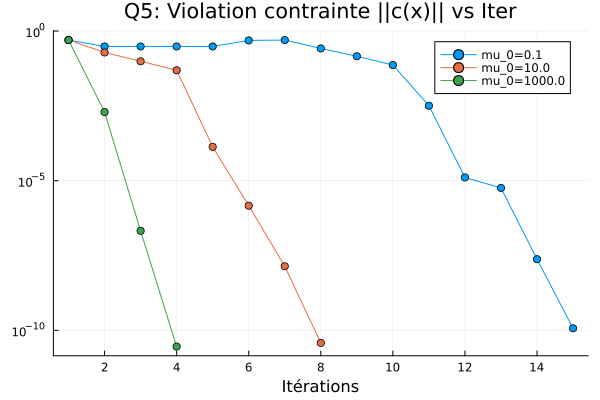

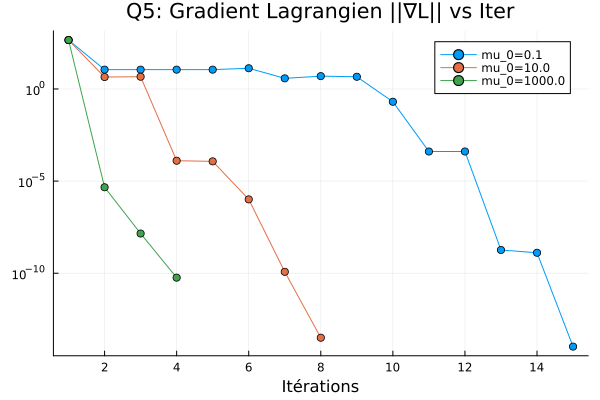

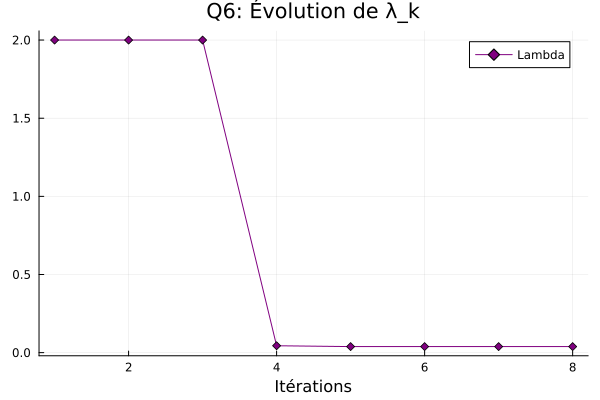

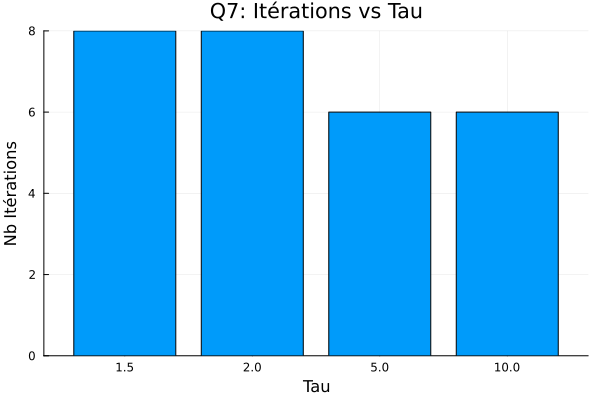

In [8]:
using Plots
using LinearAlgebra
include("../src/lagrangien_augmente.jl")
include("../test/fonctions_de_tests.jl")

# Fonction pour récupérer l'historique complet (pour Q5)
# On crée une version locale qui enregistre l'historique des contraintes et du gradient
function lagrangien_augmente_trace(f, gradf, hessf, c, gradc, hessc, x0; 
        max_iter=1000, tol_abs=1e-10, tol_rel=1e-8, λ0=2, μ0=10, τ=2, algo_noc="rc-gct")
    
    x_k = x0; λ_k = λ0; μ_k = μ0
    nb_iters = 0
    
    # Historiques
    hist_cn = Float64[] # ||c(xk)||
    hist_grad = Float64[] # ||∇LA||
    hist_mu = Float64[]
    hist_lambda = Float64[]

    # Paramètres Algo 4
    β = 0.9; η_hat = 0.1258925; α = 0.1
    ε_0 = 1.0 / μ0; η_0 = η_hat / (μ0^α)
    ε_k = ε_0; η_k = η_0
    
    while nb_iters < max_iter
        # Enregistrement des métriques avant mise à jour
        cx = c(x_k)
        grad_L = gradf(x_k) + λ_k * gradc(x_k) # Approximation du gradient Lagrangien
        push!(hist_cn, norm(cx))
        push!(hist_grad, norm(grad_L))
        push!(hist_mu, μ_k)
        push!(hist_lambda, λ_k)

        # Arrêt
        if (norm(grad_L) <= max(tol_rel, tol_abs)) && (norm(cx) <= max(tol_rel, tol_abs))
            break
        end

        # Sous-problème (définitions locales simplifiées)
        LA(x) = f(x) + λ_k * c(x) + 0.5 * μ_k * c(x)^2
        grad_LA(x) = gradf(x) + (λ_k + μ_k * c(x)) * gradc(x)
        hess_LA(x) = hessf(x) + (λ_k + μ_k * c(x)) * hessc(x) + μ_k * (gradc(x) * gradc(x)')
        
        # Résolution sous-problème
        args = (max_iter=1000, tol_abs=ε_k, tol_rel=0.0)
        x_next, _, _, _, _ = regions_de_confiance(LA, grad_LA, hess_LA, x_k; algo_pas="gct", args...)

        # Mise à jour paramètres
        if norm(c(x_next)) <= η_k
            λ_k += μ_k * c(x_next)
            ε_k /= μ_k
            η_k /= μ_k^β
        else
            μ_k *= τ
            ε_k = ε_0 / μ_k
            η_k = η_hat / (μ_k^α)
        end
        x_k = x_next
        nb_iters += 1
    end
    return x_k, hist_cn, hist_grad, hist_mu, hist_lambda
end


# RÉPONSES GRAPHIQUES

# Données du problème (fct2 avec contrainte 2)
x0 = pts2.x03 # [1, 0]

# Question 5
mu_values = [0.1, 10.0, 1000.0]
p5_c = plot(title="Q5: Violation contrainte ||c(x)|| vs Iter", yaxis=:log, xlabel="Itérations")
p5_g = plot(title="Q5: Gradient Lagrangien ||∇L|| vs Iter", yaxis=:log, xlabel="Itérations")

for mu_val in mu_values
    _, h_c, h_g, _, _ = lagrangien_augmente_trace(fct2, grad_fct2, hess_fct2, contrainte2, grad_contrainte2, hess_contrainte2, x0, μ0=mu_val)
    plot!(p5_c, h_c, label="mu_0=$mu_val", marker=:circle)
    plot!(p5_g, h_g, label="mu_0=$mu_val", marker=:circle)
end

# Question 6
_, _, _, _, h_lambda = lagrangien_augmente_trace(fct2, grad_fct2, hess_fct2, contrainte2, grad_contrainte2, hess_contrainte2, x0, μ0=10.0)
p6 = plot(h_lambda, title="Q6: Évolution de λ_k", label="Lambda", xlabel="Itérations", marker=:d, color=:purple)

# Question 7
tau_values = [1.5, 2.0, 5.0, 10.0]
iters_tau = []
for t in tau_values
    _, _, _, _, _h_mu = lagrangien_augmente_trace(fct2, grad_fct2, hess_fct2, contrainte2, grad_contrainte2, hess_contrainte2, x0, τ=t)
    push!(iters_tau, length(_h_mu))
end
p7 = bar(string.(tau_values), iters_tau, title="Q7: Itérations vs Tau", xlabel="Tau", ylabel="Nb Itérations", legend=false)

# Affichage
display(plot(p5_c))
display(plot(p5_g))
display(plot(p6))
display((p7))